# Mindestanforderungen
Entscheiden Sie, ob Sie mit der linearen Regression modellieren, prädizieren, oder beides erreichen wollen.


Führen Sie die entsprechende(n) Analyse(n) methodisch sauber durch und berichten Sie entsprechend der    eingeführten Kriterien und Evaluationsmaße das Ergebnis.


Wenn Sie sowohl modellieren als auch prädizieren wollen, führen Sie die Modellierung nur auf den Trainingsdaten durch, um zu vermeiden, dass Sie ungewollt aus Ihren Testdaten lernen. Trainieren Sie das Prädiktionsmodell im zweiten Schritt aufgrund der Erkenntnisse der Modellierung.

# Mindestanforderungen Evaluation
Definieren Sie für Ihr Modell die Frequenzbaseline bzw. die Mittelwertsbaseline.


Definieren Sie für Ihr Modell eine einfache Vergleichsbaseline.


Prüfen Sie mittels einer Lernkurve, ob Ihr Modell zu Over- oder Underfitting neigt und evaluieren Sie entsprechend des Ergebnisses ein mächtigeres oder weniger mächtiges Modell. Wenn Ihr Modell weder Over- noch Underfitting zeigt: Herzlichen Glückwunsch, es ist nichts weiter zu tun.


Interpretieren Sie Ihr Modell: Entweder mit Hilfe von LIME oder bei transparenten Algorithmen aufgrund des gelernten Modells selber.

# Lineare Regression: Einkommen vorhersagen (`ConvertedTotalComp`)



In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold


In [5]:

df = pd.read_csv("../../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

df = df[df["ConvertedCompTotal"] > 10000].copy()

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


MaxAge                                                            float64
AgeNum                                                            float64
EdLevel                                                           float64
WorkExp                                                           float64
YearsCode                                                         float64
                                                                   ...   
AIAgents_no, i use ai exclusively in copilot/autocomplete mode      int64
AIAgents_yes, i use ai agents at work daily                         int64
AIAgents_yes, i use ai agents at work monthly or infrequently       int64
AIAgents_yes, i use ai agents at work weekly                        int64
AIAgents_nan                                                        int64
Length: 544, dtype: object

In [6]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()
X = X.drop(columns=["ConvertedCompYearly"])


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (14116, 534) y: (14116,)


count     14116.000000
mean      98182.416098
std       59631.722857
min       10000.000000
25%       55029.655500
50%       85398.213056
75%      129007.724296
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [7]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
3     36435.36
7     72000.00
8     70000.00
Name: ConvertedCompTotal, dtype: float64

In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (11292, 534) Test: (2824, 534)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["MaxAge", "AgeNum", "WorkExp", "YearsCode", "RemoteCategoryNum"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


In [10]:
# Grid Search (Ridge / Lasso / ElasticNet) mit Preprocessing-Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge())  # Platzhalter
])

param_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1, 10, 100, 300, 1000]
    },
    {
        "model": [Lasso(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    {
        "model": [ElasticNet(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    }
]

#cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE minimieren
    cv=3,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("Bestes Modell:", grid.best_estimator_.named_steps["model"])
print("Beste Parameter:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

best_pipe = grid.best_estimator_
clf = best_pipe.named_steps["model"]  # für nachfolgende Zellen (Intercept / Coefs etc.)


/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.52953e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.71243e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.48865e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.71085e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/p

Bestes Modell: Ridge(alpha=10)
Beste Parameter: {'model': Ridge(), 'model__alpha': 10}
Best CV RMSE: 38113.19481780116


/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.40747e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.61494e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.58872e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.5957e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.65285e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/py

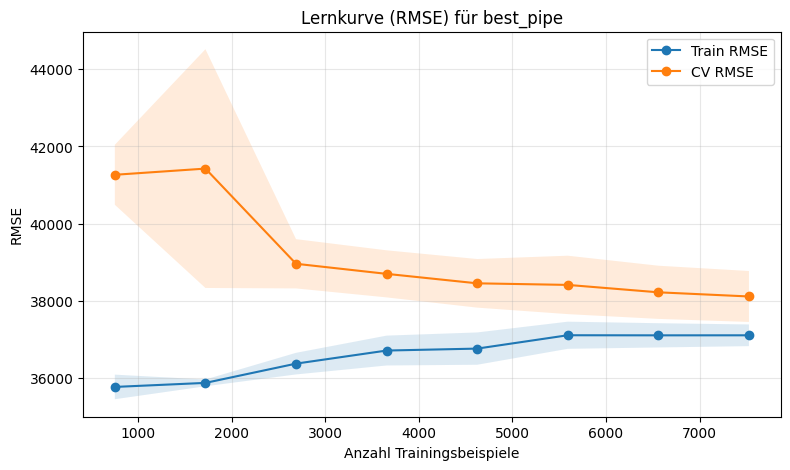

Letzter Punkt: Train RMSE=37107.4959, CV RMSE=38113.1948
Generalization Gap (CV-Train)=1005.6989  | Gap-Ratio=2.64%
Train-Baseline (Mean-Predictor) RMSE ~ std(y_train)=59454.0737
Diagnose: ok


In [20]:
from sklearn.model_selection import learning_curve, KFold
import numpy as np
import matplotlib.pyplot as plt

# Lernkurve für das bereits gefittete best_pipe (GridSearch-Bestmodell)
#cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, cv_scores = learning_curve(
    estimator=best_pipe,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# In positive RMSE umwandeln
train_rmse = -train_scores
cv_rmse = -cv_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std  = train_rmse.std(axis=1)
cv_rmse_mean    = cv_rmse.mean(axis=1)
cv_rmse_std     = cv_rmse.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_rmse_mean, marker="o", label="Train RMSE")
plt.fill_between(train_sizes, train_rmse_mean-train_rmse_std, train_rmse_mean+train_rmse_std, alpha=0.15)

plt.plot(train_sizes, cv_rmse_mean, marker="o", label="CV RMSE")
plt.fill_between(train_sizes, cv_rmse_mean-cv_rmse_std, cv_rmse_mean+cv_rmse_std, alpha=0.15)

plt.title("Lernkurve (RMSE) für best_pipe")
plt.xlabel("Anzahl Trainingsbeispiele")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Heuristische Diagnose auf Basis des letzten Punktes (größtes Trainingsset)
gap = cv_rmse_mean[-1] - train_rmse_mean[-1]
gap_ratio = gap / max(cv_rmse_mean[-1], 1e-12)

# Baseline-RMSE eines Mean-Predictors auf dem Training (als grober Referenzwert)
baseline_train_rmse = float(np.std(y_train, ddof=0))

print(f"Letzter Punkt: Train RMSE={train_rmse_mean[-1]:.4f}, CV RMSE={cv_rmse_mean[-1]:.4f}")
print(f"Generalization Gap (CV-Train)={gap:.4f}  | Gap-Ratio={gap_ratio:.2%}")
print(f"Train-Baseline (Mean-Predictor) RMSE ~ std(y_train)={baseline_train_rmse:.4f}")

# Diagnose-Regeln (praxisnah, nicht mathematisch 'perfekt')
if gap_ratio > 0.15 and train_rmse_mean[-1] < baseline_train_rmse * 0.9:
    diagnosis = "overfitting"
elif cv_rmse_mean[-1] > baseline_train_rmse * 0.90 and gap_ratio < 0.08:
    diagnosis = "underfitting"
else:
    diagnosis = "ok"

print("Diagnose:", diagnosis)


In [21]:
import pandas as pd
import numpy as np

model = best_pipe.named_steps["model"]
prep = best_pipe.named_steps["preprocess"]

# Feature-Namen aus dem ColumnTransformer ziehen
try:
    feature_names = prep.get_feature_names_out()
except Exception:
    # Fallback, falls sklearn-Version alt ist
    # (Dann sind Feature-Namen ggf. weniger sauber, aber es läuft.)
    num_cols = prep.transformers_[0][2]
    dum_cols = prep.transformers_[1][2]
    feature_names = np.array([f"num__{c}" for c in num_cols] + [f"dum__{c}" for c in dum_cols])

# Koeffizienten prüfen (nur bei linearen Modellen vorhanden)
if hasattr(model, "coef_"):
    coefs = model.coef_.ravel()
    coef_series = pd.Series(coefs, index=feature_names).sort_values(key=np.abs, ascending=False)

    print("Intercept:", getattr(model, "intercept_", None))
    display(coef_series.head(20).to_frame("coef (abs-sortiert)"))

    # Optional: getrennte Listen positive/negative Einflüsse
    print("\nTop positive Einflüsse:")
    display(coef_series.sort_values(ascending=False).head(10).to_frame("coef"))

    print("\nTop negative Einflüsse:")
    display(coef_series.sort_values(ascending=True).head(10).to_frame("coef"))
else:
    print("Das aktuelle Modell hat keine coef_. Verwende stattdessen LIME oder Permutation Importance.")


Intercept: 6888.825235671713


,coef (abs-sortiert)
dum__Country_United States of America,73629.117014
dum__Country_Israel,40730.836586
dum__Country_Switzerland,40211.721084
dum__Currency_CHF,36811.078219
dum__Country_Ireland,34282.065012
dum__OrgSize,30465.187514
"dum__Country_Venezuela, Bolivarian Republic of...",-29336.291748
dum__Country_Singapore,29199.697986
"dum__DevType_senior executive (c-suite, vp, etc.)",27316.072834
dum__Currency_IDR,-24988.221187



Top positive Einflüsse:


,coef
dum__Country_United States of America,73629.117014
dum__Country_Israel,40730.836586
dum__Country_Switzerland,40211.721084
dum__Currency_CHF,36811.078219
dum__Country_Ireland,34282.065012
dum__OrgSize,30465.187514
dum__Country_Singapore,29199.697986
"dum__DevType_senior executive (c-suite, vp, etc.)",27316.072834
dum__Currency_ILS,22890.379758
dum__Country_United Kingdom of Great Britain and Northern Ireland,22672.823212



Top negative Einflüsse:


,coef
"dum__Country_Venezuela, Bolivarian Republic of...",-29336.291748
dum__Currency_IDR,-24988.221187
dum__Currency_BRL,-22718.655567
dum__Country_Ukraine,-21690.594047
dum__DevType_academic researcher,-20458.415232
dum__Country_Greece,-20211.574226
dum__Industry_higher education,-19971.200249
dum__Country_India,-18652.667614
dum__Country_Colombia,-17347.348637
dum__Employment_student,-16726.093462


In [12]:
# Prediction + Metriken (Best Model aus Grid Search)

predicted = best_pipe.predict(X_test)
expected = y_test

test_predict_mean = np.full(len(y_test), y_train.mean())
print("Baseline Mean RMSE:")
rmse_baseline = np.sqrt(mean_squared_error(expected, test_predict_mean))
print(rmse_baseline)

print("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print(rmse)

print("R^2:")
r2 = r2_score(expected, predicted)
print(r2)

print("MAE:")
mae = mean_absolute_error(expected, predicted)
print(mae)


Baseline Mean RMSE:
60328.78978859841
RMSE:
38341.372852962486
R^2:
0.5959289557984992
MAE:
27467.940513395835


In [13]:
# (Optional) Top-Ergebnisse aus der Cross-Validation (nach RMSE sortiert)

cv_res = pd.DataFrame(grid.cv_results_)
cols_show = ["rank_test_score", "mean_test_score", "std_test_score", "params"]
cv_res_sorted = cv_res[cols_show].sort_values("rank_test_score").head(10)

# RMSE aus neg_root_mean_squared_error zurückrechnen
cv_res_sorted = cv_res_sorted.assign(
    mean_RMSE = -cv_res_sorted["mean_test_score"],
    std_RMSE = cv_res_sorted["std_test_score"]
).drop(columns=["mean_test_score", "std_test_score"])

cv_res_sorted


,rank_test_score,params,mean_RMSE,std_RMSE
3,1,"{'model': Ridge(), 'model__alpha': 10}",38113.194818,659.445068
27,2,"{'model': ElasticNet(max_iter=20000), 'model__...",38117.818844,666.773927
18,3,"{'model': ElasticNet(max_iter=20000), 'model__...",38123.567666,672.162607
19,4,"{'model': ElasticNet(max_iter=20000), 'model__...",38147.043233,692.889145
26,5,"{'model': ElasticNet(max_iter=20000), 'model__...",38190.372046,674.474203
20,6,"{'model': ElasticNet(max_iter=20000), 'model__...",38204.721351,745.659270
25,7,"{'model': ElasticNet(max_iter=20000), 'model__...",38337.621948,700.848094
21,8,"{'model': ElasticNet(max_iter=20000), 'model__...",38374.353185,921.406363
24,9,"{'model': ElasticNet(max_iter=20000), 'model__...",38501.532030,724.065445
23,10,"{'model': ElasticNet(max_iter=20000), 'model__...",38669.922334,744.463549


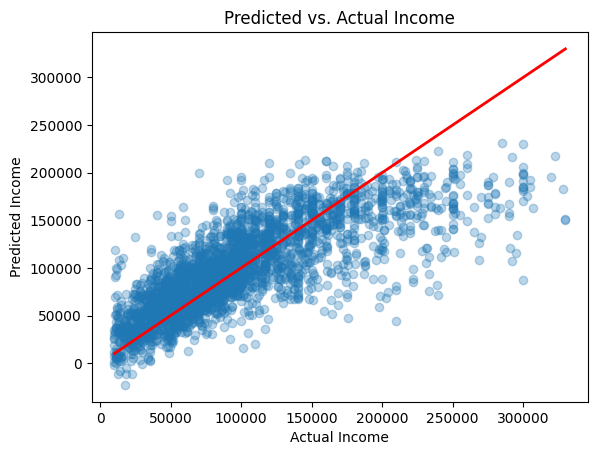

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



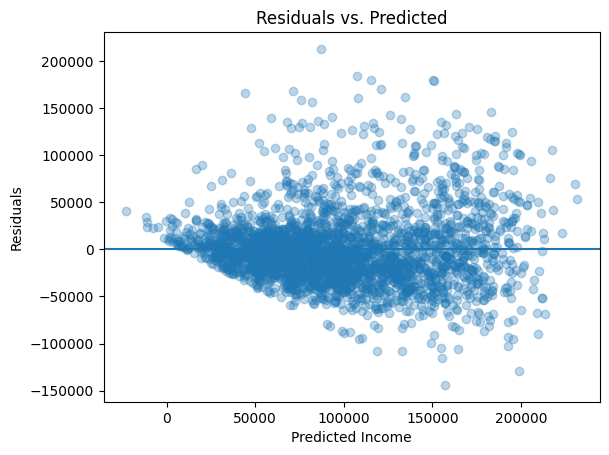

In [15]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


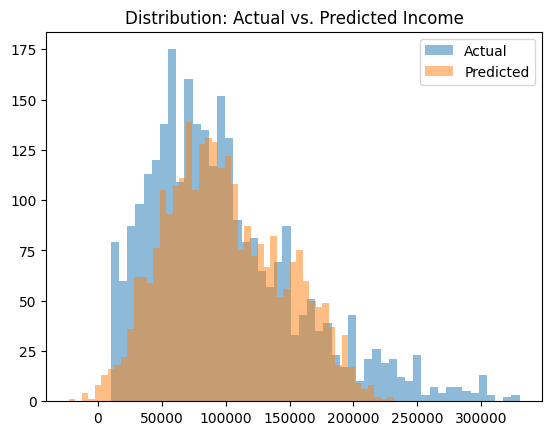

In [16]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()


In [17]:
print("Intercept:", clf.intercept_)

# Feature-Namen in der Reihenfolge des ColumnTransformers:
feature_names = num_cols + dummy_cols

coeff_df = pd.DataFrame({"Feature": feature_names, "Coefficient": clf.coef_})
print("\nFeature Coefficients:\n", coeff_df)


Intercept: 6888.825235671713

Feature Coefficients:
                                                Feature   Coefficient
0                                               MaxAge  -1505.932268
1                                               AgeNum  -3898.220954
2                                              WorkExp  13247.794566
3                                            YearsCode   6360.002116
4                                    RemoteCategoryNum  -3146.313598
..                                                 ...           ...
529  AIAgents_no, i use ai exclusively in copilot/a...  -2115.468358
530        AIAgents_yes, i use ai agents at work daily   2661.713672
531  AIAgents_yes, i use ai agents at work monthly ...   1954.756049
532       AIAgents_yes, i use ai agents at work weekly   1676.688431
533                                       AIAgents_nan  -1098.375321

[534 rows x 2 columns]


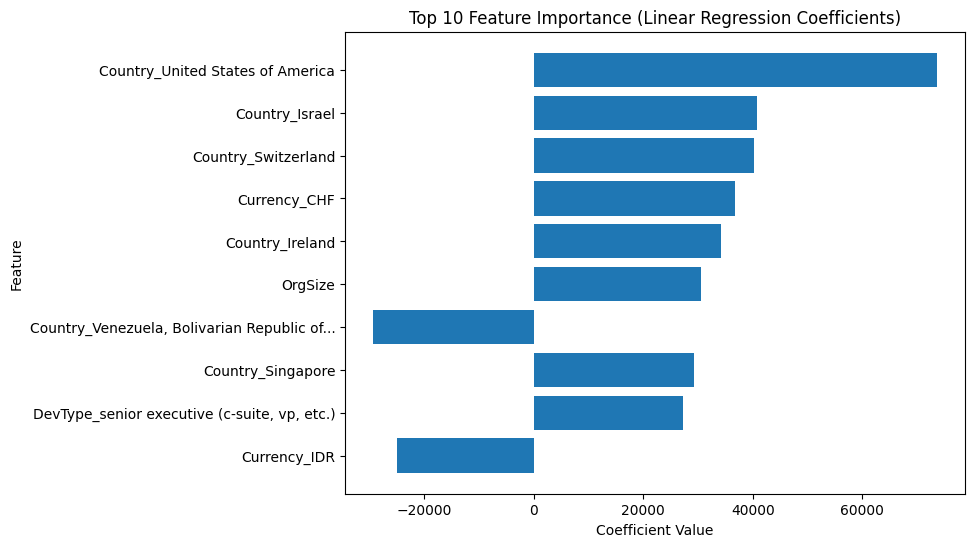

In [18]:
# Sort by absolute coefficient value and take top 10
coef_df_sorted = (
    coeff_df
    .assign(abs_coef=coeff_df["Coefficient"].abs())
    .sort_values(by="abs_coef", ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Linear Regression Coefficients)")
plt.gca().invert_yaxis()  # highest importance on top
plt.show()


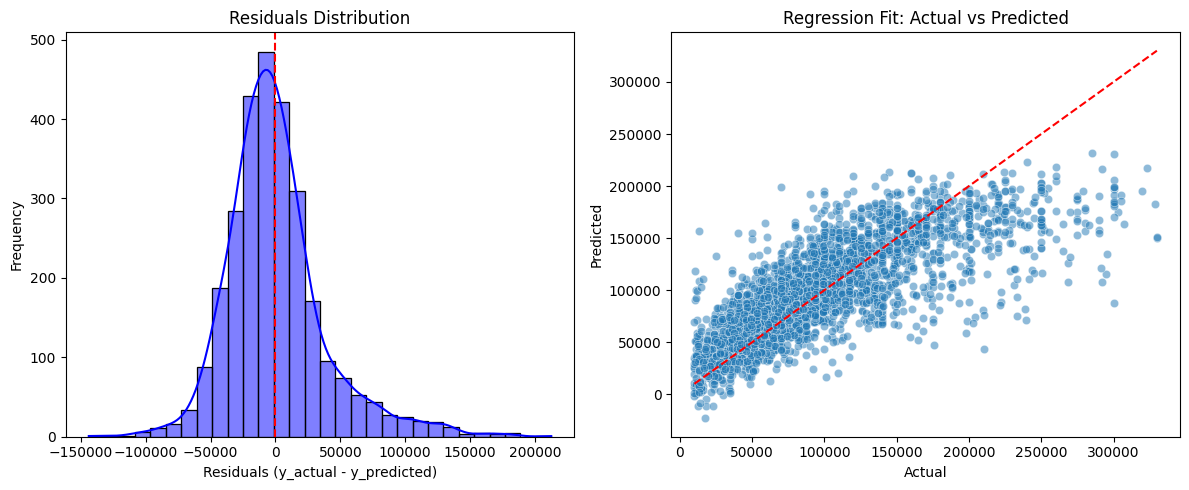

In [19]:
# Compute residuals.
residuals = expected - predicted

# Create plots.
plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=expected, y=predicted, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")


# Show plots.
plt.tight_layout()
plt.show()